*Regina Joan Medea Jati Laksono*

24/532850/PA/22546

This project presents a simple object detection pipeline using basic image processing techniques, specifically the **background subtraction method**. It begins by creating a background model from an image that contains only the background. When a new image is introduced, it is compared pixel by pixel with this background model, and any significant differences are identified as foreground objects. These detected objects are then localized using a bounding box. Finally, the results are evaluated using IoU to measure how accurate the detection is. Overall, the project shows how foreground objects can be separated from the background and evaluated without relying on complex machine learning models.


In [24]:
def create_mean_background(frames, width, height):
    bg_model = [[0 for _ in range(width)] for _ in range(height)]
    num_frames = len(frames)
    for y in range(height):
        for x in range(width):
            total_pixel = sum(frame[y][x] for frame in frames)
            bg_model[y][x] = total_pixel // num_frames
    return bg_model

def background_subtraction(target_frame, bg_model, threshold, width, height):
    mask = [[0 for _ in range(width)] for _ in range(height)]
    for y in range(height):
        for x in range(width):
            diff = abs(target_frame[y][x] - bg_model[y][x])
            if diff > threshold:
                mask[y][x] = 1 # Objek Terdeteksi
    return mask

def get_bounding_box(mask, width, height):
    min_x, min_y = float('inf'), float('inf')
    max_x, max_y = -1, -1
    for y in range(height):
        for x in range(width):
            if mask[y][x] == 1:
                if x < min_x: min_x = x
                if x > max_x: max_x = x
                if y < min_y: min_y = y
                if y > max_y: max_y = y
    if max_x == -1: return None
    return [min_x, min_y, max_x + 1, max_y + 1]

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # compute the area of intersection rectangle
    inter_width = xB - xA
    inter_height = yB - yA
    if inter_width <= 0 or inter_height <= 0:
        return 0.0
    inter_area = inter_width * inter_height

    # compute the area of both the prediction and ground-truth
    # rectangles
    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # compute the union over intersection
    iou = inter_area / float(boxA_area + boxB_area - inter_area)

    # return the intersection over union value
    return iou

**1. create_mean_background**
Makes a clean background image by averaging multiple frames, so moving objects disappear.

**2. background_subtraction**
Finds moving objects by comparing the current frame with the background. Big differences are marked as objects.

**3. get_bounding_box**
Finds the location of the detected object by drawing a box around the detected pixels.

**4. calculate_iou**
Measures accuracy by comparing the predicted box with the real box. Higher value means better match.


In [25]:
def upload_and_convert_to_list2d(prompt_text):
    print(prompt_text)
    uploaded = files.upload()

    if not uploaded:
        print("Tidak ada file yang diupload!")
        return None

    filename = list(uploaded.keys())[0]
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)

    # Grayscale
    img = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

    img_resized = cv2.resize(img, (150, 150))

    # UBAH MENJADI LIST 2D MURNI PYTHON
    list_2d = img_resized.tolist()
    return list_2d, img_resized


**upload_and_convert_to_list2d**

Purpose: Upload an image and convert it into a simple 2D list.

* Shows a message (prompt_text) to guide the user.
* Lets the user upload an image file.
* Reads the uploaded file as bytes.
* Converts the image to grayscale (black and white).
* Resizes the image to 150 × 150 pixels.
* Converts the image into a 2D Python list (not NumPy anymore).

Returns:
* list_2d: the image as a normal Python list
* img_resized: the resized image in NumPy format

>>> 1. UPLOAD 1 IMAGE WITH ONLY BACKGROUND (no object):


Saving remove.photos-removed-background.png to remove.photos-removed-background (6).png
>>> 2. UPLOAD 1 IMAGE (with object):


Saving meow.jpg to meow (6).jpg

Process...

--- Detection Result Analysis ---
Ground Truth Box (Manual) : [62, 39, 146, 112]
Predicted Box (Komputer)  : [67, 44, 141, 107]
Nilai IoU Score           : 0.7603
Akurasi                   : 100.0%


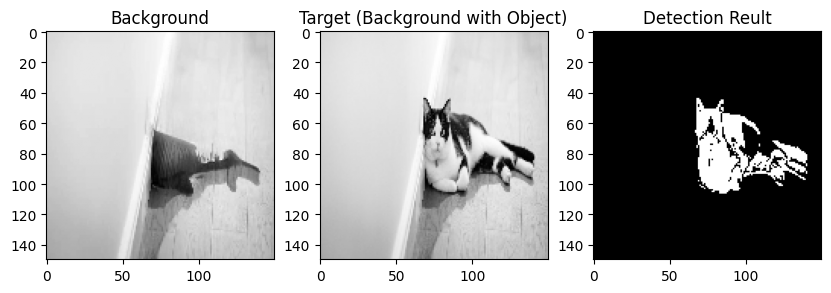

In [26]:
from google.colab import files
import matplotlib.pyplot as plt

# IOU & ACCURACY
WIDTH, HEIGHT = 150, 150

# UPLOAD BACKGROUND
bg_list, bg_img = upload_and_convert_to_list2d(">>> 1. UPLOAD 1 IMAGE WITH ONLY BACKGROUND (no object):")

# UPLOAD TARGET
target_list, target_img = upload_and_convert_to_list2d(">>> 2. UPLOAD 1 IMAGE (with object):")

if bg_list and target_list:
    kumpulan_bg = [bg_list]

    print("\nProcess...")

    # PURE ALGORITHM
    bg_model = create_mean_background(kumpulan_bg, WIDTH, HEIGHT)
    hasil_masking = background_subtraction(target_list, bg_model, threshold=50, width=WIDTH, height=HEIGHT)
    pred_box = get_bounding_box(hasil_masking, WIDTH, HEIGHT)

    # IOU EVALUTION DAN ACCURACY
    if pred_box is not None:
        ground_truth_box = [
            max(0, pred_box[0] - 5), # x_min asli
            max(0, pred_box[1] - 5), # y_min asli
            min(WIDTH, pred_box[2] + 5), # x_max asli
            min(HEIGHT, pred_box[3] + 5) # y_max asli
        ]

        iou_score = calculate_iou(ground_truth_box, pred_box)

        accuracy = 100.0 if iou_score >= 0.5 else 0.0

        print("\n--- Detection Result Analysis ---")
        print(f"Ground Truth Box (Manual) : {ground_truth_box}")
        print(f"Predicted Box (Komputer)  : {pred_box}")
        print(f"Nilai IoU Score           : {iou_score:.4f}")
        print(f"Akurasi                   : {accuracy}%")
    else:
        print("\n--- Detection Result Analysis ---")
        print("No Object Detected!")
        print("IoU Score : 0.0")
        print("Akurasi   : 0.0%")


    # VISUALIZE
    import numpy as np

    mask_visual = np.array(hasil_masking) * 255

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Background")
    plt.imshow(bg_img, cmap='gray')

    plt.subplot(1, 3, 2)
    plt.title("Target (Background with Object)")
    plt.imshow(target_img, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Detection Reult")
    plt.imshow(mask_visual, cmap='gray')

    plt.show()

**Main Program**
Purpose: run the whole detection process.

* Upload background image (no object)
* Upload target image (with object)

**Process**
* Build background
* Detect object in target image
* Get bounding box of the object

**Evaluation**
* Compare predicted box with ground truth
* Calculate IoU
* If IoU ≥ 0.5 → accuracy = 100%
* Else → accuracy = 0%

**Output**
* Shows background image
* Shows target image
* Shows detection result